## **Binary Classification**

We have $y = \{0,1\}$. Some models, like SVM, might work with $y = \{-1,1\}$.


**Loss function**

Generally, the binary cross-entropy loss function is used.

**Binary Cross-Entropy**

Models like Neural Nets, Logistic Regression use this loss function. As any loss function, the lower the better (closer to zero).

In [11]:
## BCE uses the log (natural log)

import numpy as np

## np.log -- natural log
## we want to use log(p) - natural log of prob (output) the model. 0<p<1
-np.log(0.001)

np.float64(6.907755278982137)

In [7]:
## -ln of low probabilities gives larger values
## -ln of high probabilities gives values closer to zero

In [12]:
## BCE loss function
def binary_crossentropy(y_true, p_hat):
    return -(y_true*np.log(p_hat) + (1-y_true)*np.log(1-p_hat))

In [13]:
## Example
y = 1     ## true fraud
p = 0.99  ## model says high probability of fraud

binary_crossentropy(y,p)

np.float64(0.01005033585350145)

In [14]:
## suppose y and p are vectors
y = np.array([0,   0,   0,   1,   1])
p = np.array([0.1, 0.2, 0.9, 0.7, 0.45])

binary_crossentropy(y,p)

array([0.10536052, 0.22314355, 2.30258509, 0.35667494, 0.7985077 ])

In [15]:
## BCE Cost function
def binary_crossentropy_cost(y_true, p_hat):
  return np.mean(binary_crossentropy(y_true, p_hat))

In [17]:
binary_crossentropy_cost(y,p)

np.float64(0.7572543600245172)

## **Example**

In [18]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/bank.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [25]:
## y counts
#### imbalanced?
df.y.value_counts() / len(df)

,count
y,
no,0.88476
yes,0.11524


In [26]:
## Create X and y
X = df.drop('y', axis=1)
y = df.y

In [28]:
y = y.map({'no':0, 'yes':1})

In [31]:
## Get dummy variables for categorical predictors
X = pd.get_dummies(X, drop_first=True, dtype = 'int')
X

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,30,1787,19,79,1,-1,0,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,33,4789,11,220,1,339,4,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,35,1350,16,185,1,330,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,30,1476,3,199,4,-1,0,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,59,0,5,226,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,-333,30,329,5,-1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,True
4517,57,-3313,9,153,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4518,57,295,19,151,11,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4519,28,1137,6,129,4,211,3,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [32]:
## split the data into 80% training and 20% test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 630)

In [33]:
## check
X_train.shape, X_test.shape

((3616, 42), (905, 42))

**Logistic Regression**

BCE is used. BCE is non-convex, so we need

* max_iter, n_iter
* learning_rate (step size)
* regularization: L1 or L2 or ElasticNet
* Does the model learn (converge?)

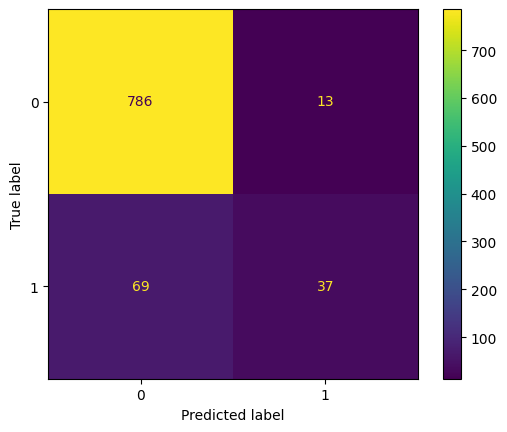

In [40]:
from sklearn.linear_model import LogisticRegression

## instance (without regularization)
lr = LogisticRegression(solver = 'liblinear', penalty = "l1")

## fit
lr.fit(X_train, y_train)

## prediction for test set
y_pred1 = lr.predict(X_test)

## Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred1)).plot()


In [41]:
## accuracy
from sklearn.metrics import accuracy_score, recall_score

accuracy_score(y_test, y_pred1)

0.9093922651933701

In [42]:
recall_score(y_test, y_pred1)

0.3490566037735849

In [43]:
## balanced accuracy
from sklearn.metrics import balanced_accuracy_score

balanced_accuracy_score(y_test, y_pred1)

np.float64(0.666393132925591)

In [44]:
## Estimates
pd.DataFrame(lr.coef_, columns = X.columns)

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,-0.011138,0.000009,0.016529,0.003919,-0.070872,-0.001403,-0.014187,-0.358954,-0.191221,-0.165376,...,-0.809726,0.231579,1.174206,-0.64718,-0.93492,1.251497,0.16712,0.085367,2.357167,-0.63109
